In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD

#  1. Carga y Exploración del Dataset CIFAR100

In [5]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']



[INFO]: Loading CIFAR-100 data...


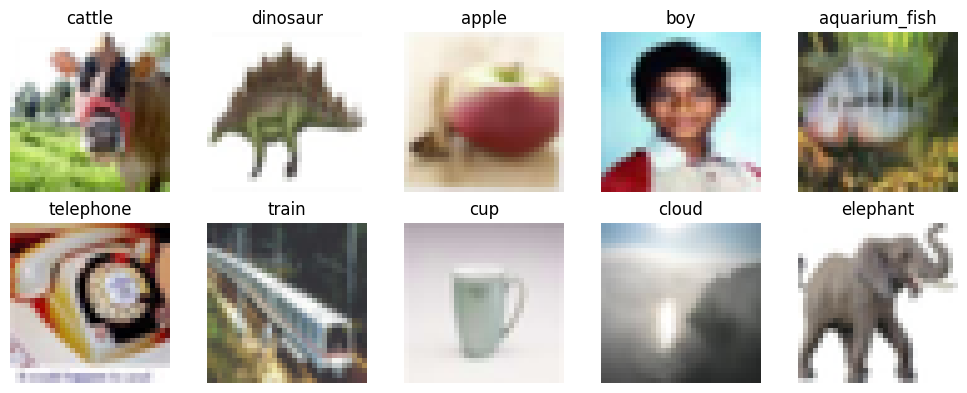

In [6]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(labelNames[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Preprocesamiento

In [7]:
# Normalizar las imágenes al rango [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [8]:
# Verificamos que las imágenes estén normalizadas
print("Mínimo y máximo después de normalizar:", np.min(x_train), np.max(x_train))

Mínimo y máximo después de normalizar: 0.0 1.0


In [9]:
# Las etiquetas están en forma de enteros, no hace falta one-hot si usamos sparse_categorical_crossentropy
# Pero si prefieres categorical_crossentropy, descomenta esta línea:
# y_train = to_categorical(y_train, 100)
# y_test = to_categorical(y_test, 100)

In [10]:
# Forma final de los datos
print("Shape de x_train:", x_train.shape)
print("Shape de y_train:", y_train.shape)

Shape de x_train: (50000, 32, 32, 3)
Shape de y_train: (50000, 1)


# 3. Data Augmentation

In [11]:
# Crear el generador con data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,          # Rota las imágenes aleatoriamente hasta 15°
    width_shift_range=0.1,      # Desplaza horizontalmente hasta un 10%
    height_shift_range=0.1,     # Desplaza verticalmente hasta un 10%
    zoom_range=0.1,             # Aplica zoom aleatorio
    horizontal_flip=True,       # Invierte horizontalmente
    fill_mode='nearest'         # Rellena los píxeles vacíos
)


In [12]:
# Ajustar el generador a los datos (opcional aquí, pero buena práctica)
datagen.fit(x_train)

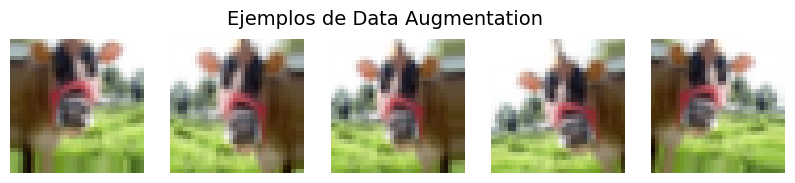

In [13]:
# Tomar una imagen de ejemplo
sample = x_train[0].reshape((1, 32, 32, 3))
plt.figure(figsize=(10,2))
for i, augmented in enumerate(datagen.flow(sample, batch_size=1)):
    plt.subplot(1, 5, i+1)
    plt.imshow(augmented[0])
    plt.axis('off')
    if i == 4:
        break
plt.suptitle("Ejemplos de Data Augmentation", fontsize=14)
plt.show()


# 4. TRANSFER LEARNING (ARQUITECTURAS PREENTRENADAS)

## 4.1 Transfer Learning con MobileNetV2

In [14]:
# Definir entrada
input_shape = (32, 32, 3)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

C:\Users\pere_\AppData\Local\Temp\ipykernel_20496\3150853233.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)


In [15]:
# Congelar capas del modelo base
base_model.trainable = False

In [16]:
# Añadir capas propias (cabezal)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(100, activation='softmax')(x)

In [17]:
# Crear modelo final
model_mobilenet = Model(inputs=base_model.input, outputs=output)

In [18]:
# Compilar el modelo
model_mobilenet.compile(optimizer=Adam(learning_rate=0.001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

model_mobilenet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,386,084 (9.10 MB)

 Trainable params: 128,100 (500.39 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
# Entrenar solo el "cabezal" (capas superiores)
history_mobilenet = model_mobilenet.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    validation_data=(x_test, y_test),
    epochs=50
)

Epoch 1/50


c:\Users\pere_\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.0327 - loss: 4.5054 - val_accuracy: 0.0898 - val_loss: 4.2658
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.0704 - loss: 4.2703 - val_accuracy: 0.1019 - val_loss: 4.1407
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.0777 - loss: 4.1915 - val_accuracy: 0.1075 - val_loss: 4.0748
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - accuracy: 0.0823 - loss: 4.1540 - val_accuracy: 0.1130 - val_loss: 4.0368
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.0865 - loss: 4.1207 - val_accuracy: 0.1158 - val_loss: 4.0082
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.0848 - loss: 4.1044 - val_accuracy: 0.1166 - val_loss: 3.9877
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.0851 - loss: 4.0879 - val_accuracy: 0.1196 - val_loss: 3.9730
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.0865 - loss: 4.0874 - val_accurac

In [20]:
# Evaluación en el conjunto de test
test_loss, test_accuracy = model_mobilenet.evaluate(x_test, y_test, verbose=2)
print(f"\n Precisión en test (sin fine-tuning): {test_accuracy:.4f}")

313/313 - 7s - 24ms/step - accuracy: 0.1270 - loss: 3.8961

 Precisión en test (sin fine-tuning): 0.1270


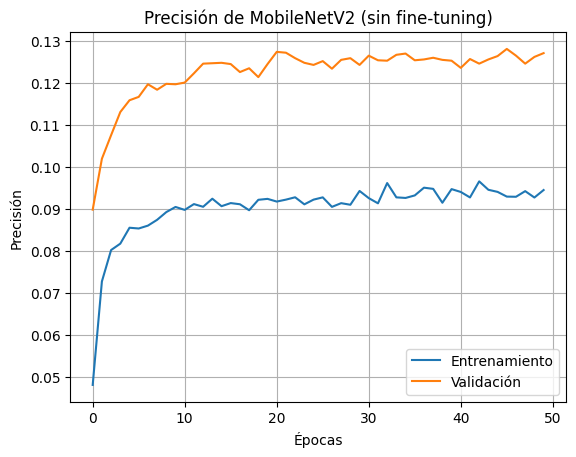

In [21]:
plt.plot(history_mobilenet.history['accuracy'], label='Entrenamiento')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validación')
plt.title('Precisión de MobileNetV2 (sin fine-tuning)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()

- Validación estable (~0.127–0.130): indica que el modelo logró cierta generalización rápida, pero se estancó.
- Entrenamiento plano (~0.093–0.096): sugiere que el modelo base (congelado) no permite aprender nuevas representaciones — solo el "cabezal" aprende.
- Esto es esperado en Transfer Learning sin fine-tuning, porque la red no se ajusta del todo al nuevo dominio.

### FINE-TUNING

In [22]:
# Descongelar desde la capa 100 en adelante (ajustable)
fine_tune_at = 100

In [23]:
# Desbloquear todo
base_model.trainable = True

In [24]:
# Solo entrenar desde cierta capa en adelante
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [25]:
# Recompilar con un LR más pequeño para fine-tuning
model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-5),  # muy bajo para no sobreajustar
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
# Entrenamiento fine-tuning
history_finetune = model_mobilenet.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=50,  # puedes ajustar
    #callbacks=callbacks
)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 79ms/step - accuracy: 0.0235 - loss: 55.1632 - val_accuracy: 0.0395 - val_loss: 16.6639
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 127s 81ms/step - accuracy: 0.0249 - loss: 9.2615 - val_accuracy: 0.0301 - val_loss: 4.9076
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.0221 - loss: 5.5494 - val_accuracy: 0.0354 - val_loss: 4.7997
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.0262 - loss: 5.1255 - val_accuracy: 0.0435 - val_loss: 4.6964
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 129s 82ms/step - accuracy: 0.0338 - loss: 4.9609 - val_accuracy: 0.0533 - val_loss: 4.5928
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.0380 - loss: 4.8806 - val_accuracy: 0.0630 - val_loss: 4.5087
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - accuracy: 0.0454 - loss: 4.8239 - val_accuracy: 0.0771 - val_loss: 4.3942
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 84ms/step - accuracy

In [27]:
# Define the combine_history function
def combine_history(history1, history2):
	combined = {}
	for key in history1.history.keys():
		combined[key] = history1.history[key] + history2.history[key]
	return combined

# Use history_mobilenet instead of history_mobilenet_cb
full_history = combine_history(history_mobilenet, history_finetune)

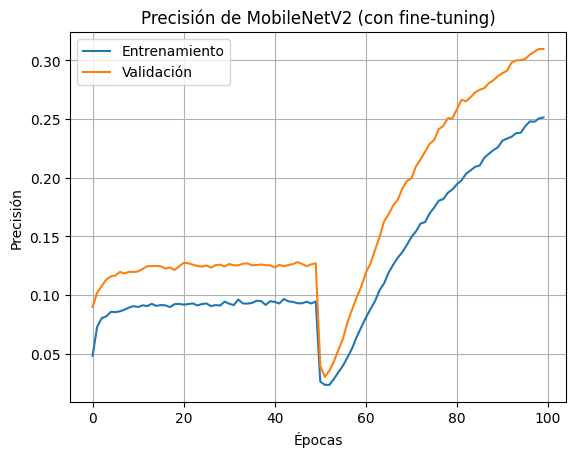

In [28]:
plt.plot(full_history['accuracy'], label='Entrenamiento')
plt.plot(full_history['val_accuracy'], label='Validación')
plt.title('Precisión de MobileNetV2 (con fine-tuning)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()

- Hasta época ~45, la precisión era estable pero baja (~0.11–0.12), típico con solo el cabezal entrenado.
- En la época ~50 hay una caída drástica: esto coincide probablemente con el punto donde comenzaste el fine-tuning y cambió el learning_rate.
- A partir de ahí, el modelo empieza a mejorar fuertemente, subiendo de forma constante.
- Termina en ~0.28 de precisión en validación, lo cual es más del doble que sin fine-tuning.

In [29]:
# Evaluar el modelo actual (entrenado con fine-tuning)
test_loss, test_accuracy = model_mobilenet.evaluate(x_test, y_test, verbose=2)
print(f"\n Precisión final en el conjunto de test: {test_accuracy:.4f}")


313/313 - 9s - 29ms/step - accuracy: 0.3097 - loss: 2.7208

 Precisión final en el conjunto de test: 0.3097


In [35]:
# Guarda el modelo en formato de Keras
model_mobilenet.save("mobilenetv2_final_P.keras")

### MODELO MobileNetV2 MEJORADO

Ajustaremos el fine-tuning (des de la capa 60) y el dropout (lo subimos a 0.5) para mejorar el modelo

In [31]:
# Desbloqueamos MobileNetV2 y aplicamos fine-tuning desde la capa 60
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Descongelar desde la capa 60 en adelante
fine_tune_at = 60
base_model.trainable = True
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

C:\Users\pere_\AppData\Local\Temp\ipykernel_20496\3702158937.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


In [32]:
# Crear nuevo "cabezal" con Dropout 0.5
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)  # <-- aquí el cambio
outputs = Dense(100, activation='softmax')(x)

model_mobilenet_v2_deep = Model(inputs=base_model.input, outputs=outputs)

In [33]:
model_mobilenet_v2_deep.compile(
    optimizer=Adam(learning_rate=1e-5),  # tasa baja por ser fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
history_deep = model_mobilenet_v2_deep.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=50,
    #callbacks=callbacks
)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 86ms/step - accuracy: 0.0140 - loss: 6.2154 - val_accuracy: 0.0220 - val_loss: 4.6028
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 148s 95ms/step - accuracy: 0.0221 - loss: 5.2856 - val_accuracy: 0.0438 - val_loss: 4.4915
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 149s 95ms/step - accuracy: 0.0310 - loss: 4.7300 - val_accuracy: 0.0688 - val_loss: 4.3329
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 148s 95ms/step - accuracy: 0.0443 - loss: 4.5177 - val_accuracy: 0.0934 - val_loss: 4.2002
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 88ms/step - accuracy: 0.0594 - loss: 4.3911 - val_accuracy: 0.1102 - val_loss: 4.0646
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 88ms/step - accuracy: 0.0737 - loss: 4.2866 - val_accuracy: 0.1301 - val_loss: 3.9417
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - accuracy: 0.0872 - loss: 4.1862 - val_accuracy: 0.1463 - val_loss: 3.8120
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 157s 100ms/step - accuracy:

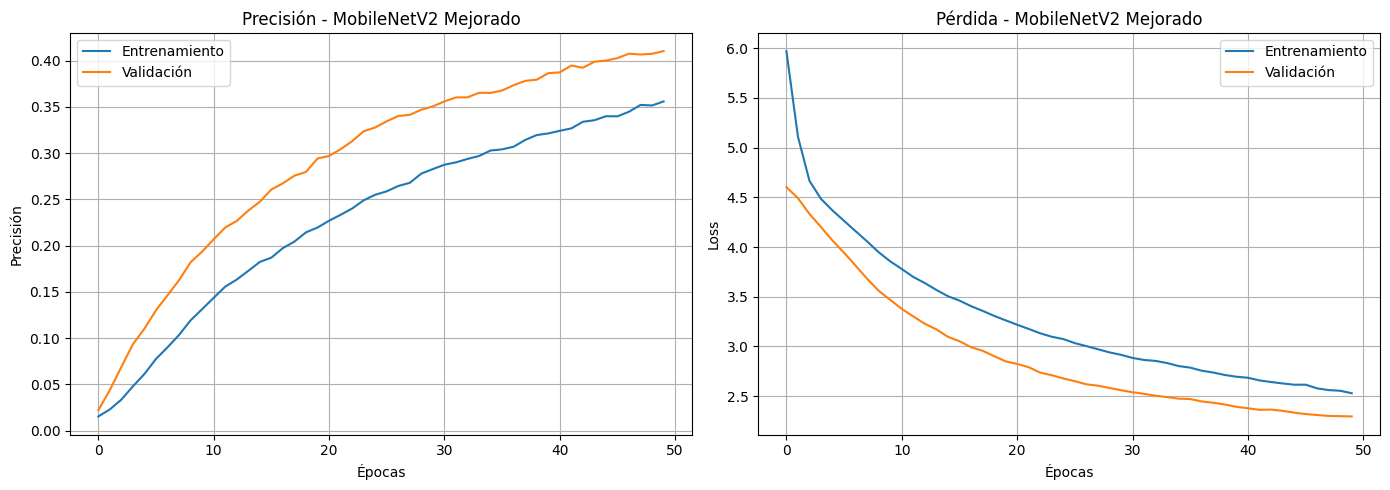

In [37]:
# Crear figura con dos subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Accuracy
axs[0].plot(history_deep.history['accuracy'], label='Entrenamiento')
axs[0].plot(history_deep.history['val_accuracy'], label='Validación')
axs[0].set_title('Precisión - MobileNetV2 Mejorado')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Precisión')
axs[0].legend()
axs[0].grid(True)

# Subplot 2: Loss
axs[1].plot(history_deep.history['loss'], label='Entrenamiento')
axs[1].plot(history_deep.history['val_loss'], label='Validación')
axs[1].set_title('Pérdida - MobileNetV2 Mejorado')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# Mostrar ambos
plt.tight_layout()
plt.show()

In [38]:
# Evaluamos modelo anterior
model_mobilenet.evaluate(x_test, y_test)

# Evaluamos el nuevo modelo mejorado
test_loss_deep, test_acc_deep = model_mobilenet_v2_deep.evaluate(x_test, y_test)
print(f" Precisión en test - MobileNetV2 mejorado: {test_acc_deep:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.3122 - loss: 2.7108
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.4146 - loss: 2.2783
 Precisión en test - MobileNetV2 mejorado: 0.4104


- La precisión de entrenamiento sube de forma constante y saludable.
- La precisión de validación es más alta que la de entrenamiento → ¡muy buena señal! Significa que el modelo está generalizando bien y no está sobreajustando.

- La pérdida en validación disminuye continuamente, lo que indica aprendizaje sólido y estable.
- Muy poca diferencia entre loss de entrenamiento y validación, lo que implica un modelo bien balanceado.

- MobileNetV2 (base):	Precisión-31.22%	Pérdida2.71%
- MobileNetV2 Mejorado (FT60 + Dropout 0.5):	Precisión-41.46%	Pérdida-2.27%

🔼 Mejora del 10,25% en precisión absoluta con apenas un par de ajustes bien aplicados.

📉 Pérdida significativamente menor, lo que indica un modelo más seguro y con mejor ajuste.

🧠 El modelo está aprendiendo representaciones más útiles del dominio CIFAR-100 gracias al fine-tuning más profundo y la regularización.

## 4.2 Transfer Learning con ResNet50